In [1]:
import os
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import linregress

### Inputs

In [2]:
stmary_seg= '/home/paul.coderre/research/SMM_Models/hype/geospacial/misc/stmary_seg'

geodata= '/home/paul.coderre/research/SMM_Models/hype/model/v10_model/final_model/hds_v1/GeoData.txt'

hist_path= '/home/paul.coderre/research/SMM_Models/hype/model/v10_model/final_model/hds_v1/'

future_path= '/home/paul.coderre/research/future_climate/scripts/official_forcings/'

var= 'Pobs'

### Pre Processing

In [3]:
# read st mary seg
with open(stmary_seg, 'r') as file:
    stm_seg= [int(line.strip()) for line in file]

# Convert stm_seg list to a set of integers
stm_seg_set = set(map(int, stm_seg))

In [4]:
geodata = pd.read_csv(geodata, index_col=0, sep='\t')

In [5]:
# Assuming 'geodata' is your DataFrame
geodata['index'] = geodata.index.astype(int)  # Ensure index is an integer
area_dict = geodata.set_index('index')['area'].to_dict()  # Create the dictionary

In [6]:
# Compute the sums
stm_area = sum(value for key, value in area_dict.items() if key in stm_seg_set)
milk_area = sum(value for key, value in area_dict.items() if key not in stm_seg_set)

### Analysis

In [7]:
def compute_weighted_averages_from_dir(directory, file_string, stm_seg_set, area_dict, stm_area, milk_area):
    """
    Processes all files in a directory matching the file_string, computes weighted averages for each file,
    and combines them into an xarray DataArray.

    Parameters:
    - directory: str, path to the directory containing the CSV files.
    - file_string: str, string that should be present in the filenames to be processed.
    - stm_seg_set: set, columns that belong to stm.
    - area_dict: dict, mapping of column headers to area values.
    - stm_area: float, total area for stm.
    - milk_area: float, total area for milk.

    Returns:
    - result_dataarray: xarray.DataArray containing merged DataFrames for each file.
    """
    # List files in the directory that match the file_string
    matching_files = [f for f in os.listdir(directory) if file_string in f and f.endswith('.txt')]

    print(matching_files)

    # Initialize an empty list to store the merged DataFrames
    merged_list = []

    # Process each matching file
    for file in matching_files:

        print(f'Processing: {file}')
              
        file_path = os.path.join(directory, file)

        # Read CSV
        pobs = pd.read_csv(file_path, index_col=0, sep='\t')
        pobs.index = pd.to_datetime(pobs.index)
        pobs.columns = pobs.columns.astype(int)

        # Select columns
        stm = pobs.loc[:, pobs.columns.isin(stm_seg_set)]
        milk = pobs.loc[:, ~pobs.columns.isin(stm_seg_set)]

        # Compute weighted sum and divide by respective areas
        stm_weighted_avg = (stm * stm.columns.map(area_dict)).sum(axis=1) / stm_area
        milk_weighted_avg = (milk * milk.columns.map(area_dict)).sum(axis=1) / milk_area

        # Combine results into a single DataFrame
        merged_df = pd.DataFrame({
            'stm_weighted_avg': stm_weighted_avg,
            'milk_weighted_avg': milk_weighted_avg
        })

        # Add the merged_df to the list
        merged_list.append(merged_df)

    # Combine all DataFrames into a single xarray DataArray
    result_dataarray = xr.concat([xr.DataArray(df, dims=["time", "region"], coords={"time": df.index, "region": df.columns}) for df in merged_list], dim="file")

    return result_dataarray

In [8]:
def plot_timeseries(result_dataarray, date_range=None, plot_trend=False):
    """
    Plots time series of stm_weighted_avg and milk_weighted_avg for each file in result_dataarray.
    Also plots the mean across all files and a shaded region between the min and max values.
    Optionally, plots a linear regression trend line.

    Parameters:
    - result_dataarray: xarray.DataArray containing weighted averages for multiple files.
    - date_range: tuple (start_date, end_date) in 'YYYY-MM-DD' format (optional).
                  If provided, trims the plot to this date range.
    - plot_trend: bool, whether to plot a linear regression trend line.
    """
    # Extract time values
    time = pd.to_datetime(result_dataarray.coords["time"].values)
    numeric_time = np.arange(len(time))  # Convert time to numeric for regression

    # Apply date range filtering if provided
    if date_range:
        start_date, end_date = pd.to_datetime(date_range)
        mask = (time >= start_date) & (time <= end_date)
    else:
        mask = slice(None)  # No filtering

    # Define colors
    mean_color = "#1f78b4"  # Soft blue for mean line
    shade_color = "#a6cee3"  # Light blue for shaded region
    trend_color = "#e31a1c"  # Red for trend line

    # Create figure and axes
    fig, axes = plt.subplots(2, 1, figsize=(18, 6), sharex=True)

    for i, region in enumerate(["stm_weighted_avg", "milk_weighted_avg"]):
        # Extract data for the current region
        data = result_dataarray.sel(region=region)

        # Compute mean, min, and max across all files
        mean_values = data.mean(dim="file")
        min_values = data.min(dim="file")
        max_values = data.max(dim="file")

        # Apply date filtering
        time_filtered = time[mask]
        mean_filtered = mean_values[mask]
        min_filtered = min_values[mask]
        max_filtered = max_values[mask]

        # Convert filtered time to numeric indices for regression
        numeric_time_filtered = np.arange(len(time_filtered))

        # Plot mean as a bold line
        axes[i].plot(time_filtered, mean_filtered, color=mean_color, lw=1, label="Mean")

        # Plot shaded area between min and max
        axes[i].fill_between(time_filtered, min_filtered, max_filtered, color=shade_color, alpha=0.5, label="Min-Max Range")

        # Plot linear trend if enabled
        if plot_trend:
            # Fit a linear trend (1st degree polynomial)
            trend_coeffs = np.polyfit(numeric_time_filtered, mean_filtered, 1)
            trend_line = np.polyval(trend_coeffs, numeric_time_filtered)

            # Plot trend line
            axes[i].plot(time_filtered, trend_line, color=trend_color, linestyle="--", lw=1.5, label="Linear Trend")

        # Formatting
        axes[i].set_title(region.replace("_", " ").title(), fontsize=14)
        axes[i].set_ylabel("Precip (mm)", fontsize=12)

    axes[1].set_xlabel("Time", fontsize=12)

    # Create a manual legend
    handles = [
        plt.Line2D([0], [0], color=mean_color, lw=2, label="Mean"),
        plt.Rectangle((0, 0), 1, 1, color=shade_color, alpha=0.5, label="Min-Max Range")
    ]
    
    if plot_trend:
        handles.append(plt.Line2D([0], [0], color=trend_color, linestyle="--", lw=1.5, label="Linear Trend"))

    fig.legend(handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=12)

    # Adjust layout and show plot
    plt.tight_layout()
    plt.show()

In [9]:
def plot_annual_means(future_annual_mean, hist_annual_mean, region_names=None, start_date=None, end_date=None, calculate_stats=True):
    """
    Plots the annual mean values for future and historical data, including uncertainty bands.
    Optionally computes summary statistics including mean, standard deviation, and trend slope.

    Parameters:
    - future_annual_mean (xarray.DataArray): Future dataset with dimensions (time, file, region).
    - hist_annual_mean (xarray.DataArray): Historical dataset with dimensions (time, file, region).
    - region_names (list, optional): List of region names corresponding to the `region` dimension.
    - start_date (str, optional): Start date for trimming the data (format: 'YYYY-MM-DD'). Defaults to None (no trimming).
    - end_date (str, optional): End date for trimming the data (format: 'YYYY-MM-DD'). Defaults to None (no trimming).
    - calculate_stats (bool, optional): Whether to compute summary statistics. Defaults to True.

    Returns:
    - summary_df (pandas.DataFrame or None): DataFrame containing summary statistics if `calculate_stats` is True, else None.
    """

    # Define colors
    mean_color = "#1f78b4"  # Soft blue for mean line
    shade_color = "#a6cee3"  # Light blue for shaded region

    # Trim data if date range is provided
    if start_date and end_date:
        future_trimmed = future_annual_mean.sel(time=slice(start_date, end_date))
        hist_trimmed = hist_annual_mean.sel(time=slice(start_date, end_date))
    else:
        future_trimmed = future_annual_mean
        hist_trimmed = hist_annual_mean

    # Compute mean, min, and max across 'file' dimension
    future_mean = future_trimmed.mean(dim="file")
    future_min = future_trimmed.min(dim="file")
    future_max = future_trimmed.max(dim="file")

    hist_mean = hist_trimmed.mean(dim="file")
    hist_min = hist_trimmed.min(dim="file")
    hist_max = hist_trimmed.max(dim="file")

    # Set default region names if not provided
    if region_names is None:
        region_names = [f"Region {i}" for i in range(future_mean.sizes["region"])]

    # Ensure region names match data dimensions
    assert len(region_names) == future_mean.sizes["region"], "Mismatch between region names and data dimensions."

    # Create subplots
    fig, axes = plt.subplots(nrows=len(region_names), figsize=(18, 6), sharex=True)

    # Store summary statistics if enabled
    summary_stats_list = []

    for r, region in enumerate(region_names):
        ax = axes[r] if len(region_names) > 1 else axes

        # Plot mean
        ax.plot(future_mean.time, future_mean[:, r], label="Ouranos Mean", color=mean_color)
        ax.plot(hist_mean.time, hist_mean[:, r], label="Historical", color="red")

        # Shade between min and max
        ax.fill_between(future_mean.time, future_min[:, r], future_max[:, r], color=shade_color, alpha=0.4, label="Ouranos Range")

        # If statistics should be computed
        if calculate_stats:
            # Extract time values as numeric (for trend calculation)
            time_numeric = future_mean.time.astype(int) / 10**9  # Convert from nanoseconds to seconds for stability

            # Compute standard deviations
            std_dev_ensemble = future_mean[:, r].std().item()
            std_dev_hist = hist_mean[:, r].std().item()

            # Compute trend slopes using np.polyfit (linear fit)
            ensemble_slope, _ = np.polyfit(time_numeric, future_mean[:, r], 1)
            hist_slope, _ = np.polyfit(time_numeric, hist_mean[:, r], 1)

            # Append summary statistics
            summary_stats_list.append([region, future_mean[:, r].mean().item(), hist_mean[:, r].mean().item(), 
                                       std_dev_ensemble, std_dev_hist, ensemble_slope, hist_slope])

        # Updated plot title using region names
        ax.set_title(f'{region}')
        ax.set_ylabel("Temperature (C)")
        ax.legend()

    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()

    # Convert summary statistics to DataFrame if calculated
    if calculate_stats:
        summary_df = pd.DataFrame(summary_stats_list, columns=[
            "Region", "Mean Ensemble", "Mean RDRS", "Std Dev Ensemble", "Std Dev RDRS", "Trend Slope Ensemble", "Trend Slope RDRS"
        ])
        return summary_df
    else:
        return None

In [10]:
def process_average_annual(future_forcings, start_year, end_year):
    """
    Computes and plots the average annual cycle of a given xarray DataArray.
    
    Parameters:
    - future_forcings (xarray.DataArray): Input data with dimensions (time, file, region).
    - start_year (int): Start year for trimming the dataset.
    - end_year (int): End year for trimming the dataset.
    """
    # Sort and filter dataset by the specified year range
    future_forcings = future_forcings.sortby('time')
    future_forcings = future_forcings.sel(time=(future_forcings['time'].dt.year >= start_year) & 
                                          (future_forcings['time'].dt.year <= end_year))

    # Compute the mean for each day of the year across all years *per file*
    average_annual_runoff = future_forcings.groupby('time.dayofyear').mean(dim='time')

    # Now take the mean across all files
 #   average_annual_runoff = daily_mean_per_file.mean(dim='file')

    # Drop leap day (dayofyear = 366)
    average_annual_runoff = average_annual_runoff.sel(dayofyear=~(average_annual_runoff['dayofyear'] == 366))

    # Shift to start on October 1st
    dayofyear_shifted = ((average_annual_runoff['dayofyear'] - 274) % 365) + 1
    average_annual_runoff = average_annual_runoff.assign_coords(dayofyear=dayofyear_shifted).sortby('dayofyear')


    return average_annual_runoff

In [11]:
def process_average_monthly(future_forcings, start_year, end_year):
    """
    Computes and plots the average monthly cycle of a given xarray DataArray.
    
    Parameters:
    - future_forcings (xarray.DataArray): Input data with dimensions (time, file, region).
    - start_year (int): Start year for trimming the dataset.
    - end_year (int): End year for trimming the dataset.
    """
    # Sort and filter dataset by the specified year range
    future_forcings = future_forcings.sortby('time')
    future_forcings = future_forcings.sel(time=(future_forcings['time'].dt.year >= start_year) & 
                                          (future_forcings['time'].dt.year <= end_year))

    # Resample to monthly data and compute the sum
    monthly_sum = future_forcings.resample(time='1MS').sum(dim='time')
    
    # Calculate the mean for each month (Jan, Feb, ..., Dec)
    monthly_mean = monthly_sum.groupby('time.month').mean(dim='time')
    
    #     # Drop leap day (dayofyear = 366)
    # average_annual_runoff = average_annual_runoff.sel(dayofyear=~(average_annual_runoff['dayofyear'] == 366))

    # # Shift to start on October 1st
    # dayofyear_shifted = ((average_annual_runoff['dayofyear'] - 274) % 365) + 1
    # average_annual_runoff = average_annual_runoff.assign_coords(dayofyear=dayofyear_shifted).sortby('dayofyear')

    return monthly_mean

In [12]:
historical_forcings = compute_weighted_averages_from_dir(
    directory=hist_path,
    file_string=var,  # e.g., 'pobs'
    stm_seg_set=stm_seg_set,
    area_dict=area_dict,
    stm_area=stm_area,
    milk_area=milk_area
)

['Pobs.txt']
Processing: Pobs.txt


In [13]:
future_forcings = compute_weighted_averages_from_dir(
    directory=future_path,
    file_string=var,  # e.g., 'pobs'
    stm_seg_set=stm_seg_set,
    area_dict=area_dict,
    stm_area=stm_area,
    milk_area=milk_area
)

['05_easymore_cmip_outs_INM_INM-CM5-0_ssp245_Pobs.txt', '20_easymore_cmip_outs_CAS_FGOALS-g3_ssp245_Pobs.txt', '31_easymore_cmip_outs_DKRZ_MPI-ESM1-2-HR_ssp370_Pobs.txt', '11_easymore_cmip_outs_NCC_NorESM2-LM_ssp245_Pobs.txt', '24_easymore_cmip_outs_CMCC_CMCC-ESM2_ssp245_Pobs.txt', '26_easymore_cmip_outs_CSIRO_ACCESS-ESM1-5_ssp245_Pobs.txt', '03_easymore_cmip_outs_INM_INM-CM5-0_ssp370_Pobs.txt', '51_easymore_cmip_outs_MIROC_MIROC-ES2L_ssp245_Pobs.txt', '46_easymore_cmip_outs_MPI-M_MPI-ESM1-2-LR_ssp245_Pobs.txt', '67_easymore_cmip_outs_NIMS-KMA_KACE-1-0-G_ssp370_Pobs.txt', '56_easymore_cmip_outs_CSIRO-ARCCSS_ACCESS-CM2_ssp245_Pobs.txt', '29_easymore_cmip_outs_DKRZ_MPI-ESM1-2-HR_ssp245_Pobs.txt', '18_easymore_cmip_outs_CAS_FGOALS-g3_ssp370_Pobs.txt', '16_easymore_cmip_outs_NOAA-GFDL_GFDL-ESM4_ssp370_Pobs.txt', '23_easymore_cmip_outs_CMCC_CMCC-ESM2_ssp370_Pobs.txt', '15_easymore_cmip_outs_NOAA-GFDL_GFDL-ESM4_ssp245_Pobs.txt', '09_easymore_cmip_outs_NCC_NorESM2-LM_ssp370_Pobs.txt', '50_eas

In [14]:
historical_forcings

<xarray.DataArray (file: 1, time: 17897, region: 2)> Size: 286kB
array([[[0.10731294, 0.03662081],
        [0.15241341, 0.43745814],
        [0.56885725, 0.81009576],
        ...,
        [2.48014605, 0.06678322],
        [5.50405556, 1.40371721],
        [0.39681964, 0.22929782]]])
Coordinates:
  * time     (time) datetime64[ns] 143kB 1970-01-01 1970-01-02 ... 2018-12-31
  * region   (region) object 16B 'stm_weighted_avg' 'milk_weighted_avg'
Dimensions without coordinates: file

In [15]:
# Assume `da` is your DataArray
hist_annual_mean = historical_forcings.resample(time="YE").mean()
future_annual_mean = future_forcings.resample(time="YE").mean()

In [16]:
# # Historical plot
# plot_timeseries(historical_forcings) # date_range=("2000-01-01", "2010-12-31")

In [17]:
# # Historical plot
# plot_timeseries(future_forcings) # date_range=("2000-01-01", "2010-12-31")

In [18]:
# # Historical plot
# plot_timeseries(hist_annual_mean, plot_trend=True) # date_range=("2000-01-01", "2010-12-31")

In [19]:
# # Historical plot
# plot_timeseries(future_annual_mean,plot_trend=True) # date_range=("2000-01-01", "2010-12-31")

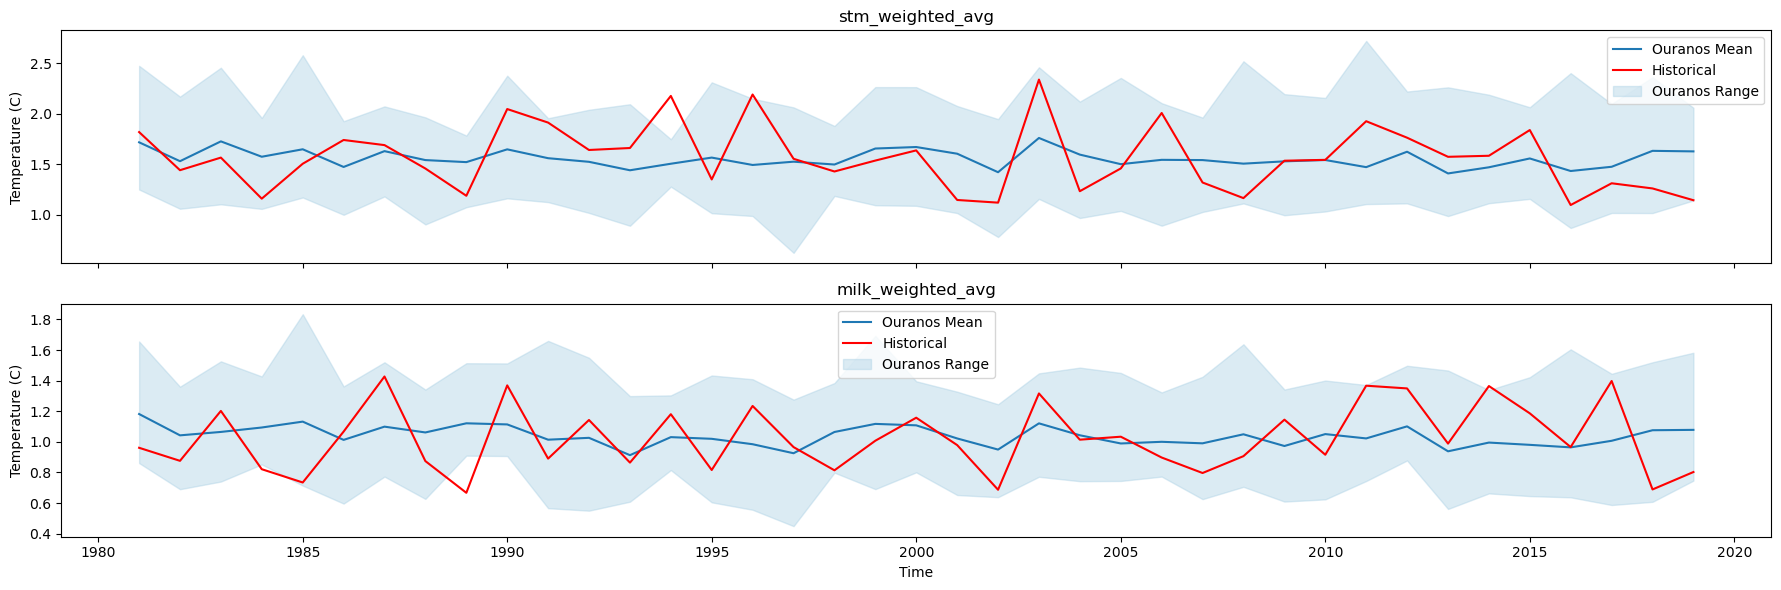

In [20]:
timeseries_stats= plot_annual_means(future_annual_mean, hist_annual_mean, region_names=["stm_weighted_avg", "milk_weighted_avg"], start_date='1980-01-01', end_date='2018-12-31',calculate_stats=True) 

In [21]:
timeseries_stats

,Region,Mean Ensemble,Mean RDRS,Std Dev Ensemble,Std Dev RDRS,Trend Slope Ensemble,Trend Slope RDRS
0,stm_weighted_avg,1.557463,1.567002,0.084566,0.318457,-6.531659e-11,-1.659746e-10
1,milk_weighted_avg,1.038077,1.022593,0.061887,0.216587,-6.263255e-11,8.061222e-11


In [22]:
average_annual_future= process_average_annual(future_forcings, 1980, 2018)
average_annual_historical= process_average_annual(historical_forcings, 1980, 2018)

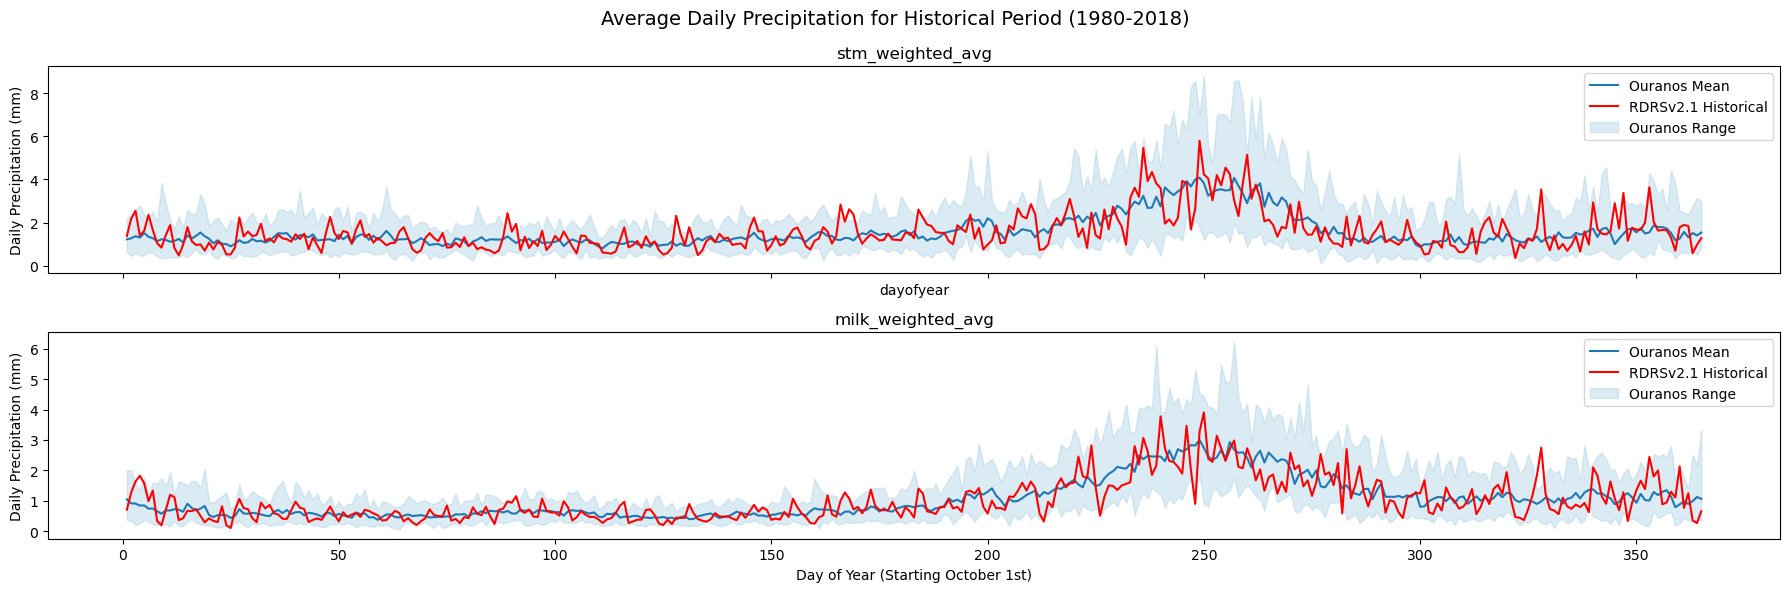

In [23]:
# Example region names
region_names = ["stm_weighted_avg", "milk_weighted_avg"]

# Define colors
mean_color = "#1f78b4"  # Soft blue for mean line
shade_color = "#a6cee3"  # Light blue for shaded region

# Compute mean, min, and max across 'file' dimension
future_mean = average_annual_future.mean(dim="file")
future_min = average_annual_future.min(dim="file")
future_max = average_annual_future.max(dim="file")

hist_mean = average_annual_historical.mean(dim="file")
hist_min = average_annual_historical.min(dim="file")
hist_max = average_annual_historical.max(dim="file")

# Ensure region names match data dimensions
assert len(region_names) == future_mean.sizes["region"], "Mismatch between region names and data dimensions."

# Create subplots
fig, axes = plt.subplots(nrows=len(region_names), figsize=(18, 6), sharex=True)

for r, region in enumerate(region_names):
    ax = axes[r] if len(region_names) > 1 else axes

    # Plot the future and historical mean, selecting based on region index
    future_mean.isel(region=r).plot(ax=ax, color=mean_color, linestyle='-', label="Ouranos Mean")
    hist_mean.isel(region=r).plot(ax=ax, color="red", linestyle='-', label="RDRSv2.1 Historical")

    # Shade between min and max for future data
    ax.fill_between(
        future_mean.coords['dayofyear'],  # Access the time coordinate
        future_min.isel(region=r), 
        future_max.isel(region=r), 
        color=shade_color, 
        alpha=0.4, 
        label="Ouranos Range"
    )

    # If you have a specific range (like mreib_ssp245), you could use a similar approach here:
    # ax.fill_between(future_mean.coords['time'], future_min.isel(region=r), mreib_ssp245, color=shade_color, alpha=0.2)

    # Updated plot title using region names
    ax.set_title(f'{region}')
    ax.set_ylabel("Daily Precipitation (mm)")
    ax.legend()

# Set the xlabel only on the last subplot
axes[-1].set_xlabel("Day of Year (Starting October 1st)")

# Add super title to the entire figure
fig.suptitle('Average Daily Precipitation for Historical Period (1980-2018)', fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
average_monthly_future= process_average_monthly(future_forcings, 1980, 2018)
average_monthly_historical= process_average_monthly(historical_forcings, 1980, 2018)

In [25]:
average_monthly_historical

<xarray.DataArray (file: 1, month: 12, region: 2)> Size: 192B
array([[[32.67850649, 17.70643491],
        [33.02738263, 13.73679424],
        [44.89756227, 22.31692626],
        [50.76667487, 29.79020884],
        [73.44919802, 57.35736594],
        [92.72830293, 66.29893642],
        [39.88864187, 40.91539657],
        [40.10967769, 32.8489742 ],
        [50.46500498, 34.89616227],
        [40.06414877, 23.41000996],
        [39.62749238, 16.75861641],
        [34.63174561, 17.46025714]]])
Coordinates:
  * region   (region) object 16B 'stm_weighted_avg' 'milk_weighted_avg'
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: file

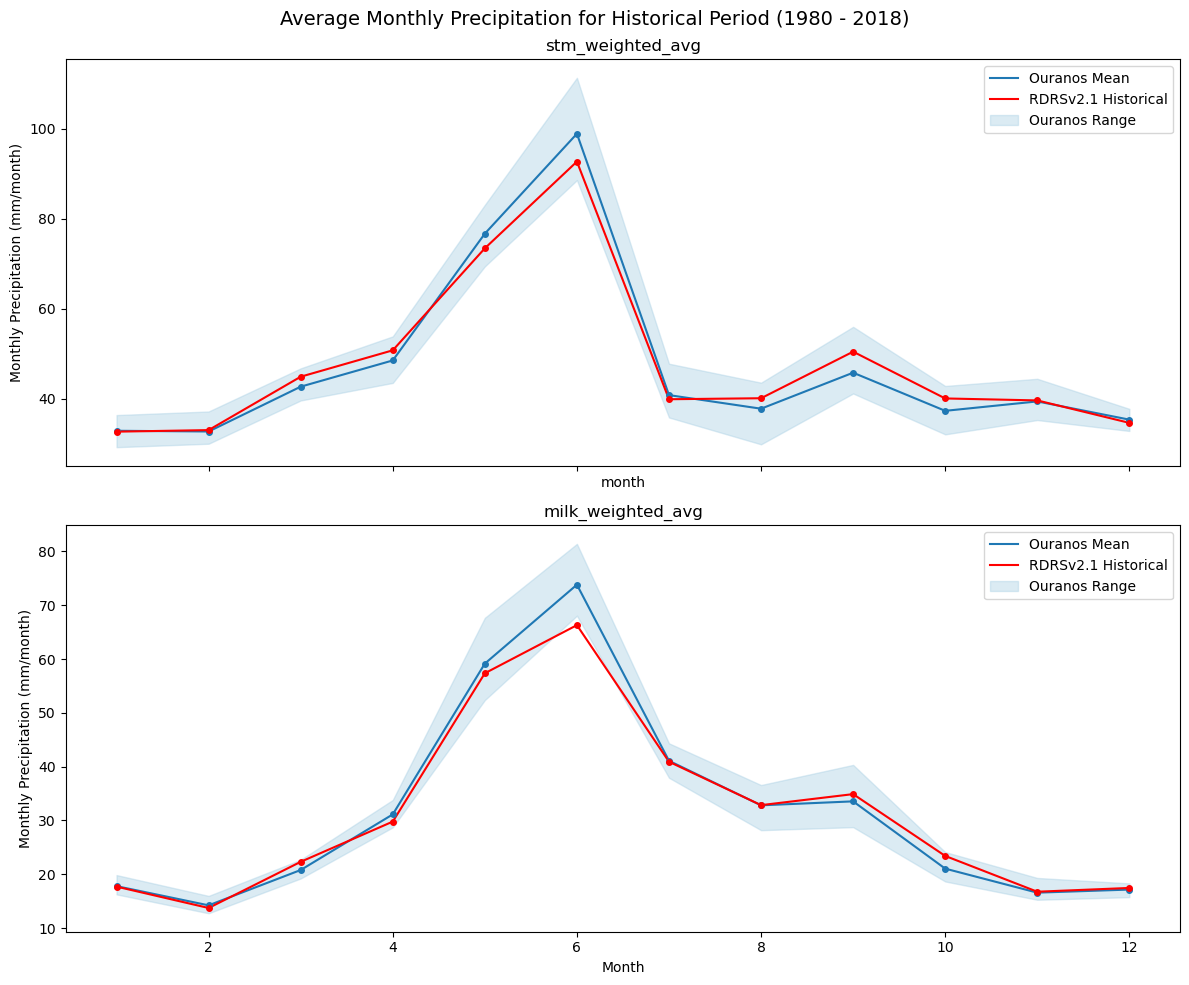

In [26]:
# Example region names
region_names = ["stm_weighted_avg", "milk_weighted_avg"]

# Define colors
mean_color = "#1f78b4"  # Soft blue for mean line
shade_color = "#a6cee3"  # Light blue for shaded region

# Compute mean, min, and max across 'file' dimension
mfuture_mean = average_monthly_future.mean(dim="file")
mfuture_min = average_monthly_future.min(dim="file")
mfuture_max = average_monthly_future.max(dim="file")

mhist_mean = average_monthly_historical.mean(dim="file")
mhist_min = average_monthly_historical.min(dim="file")
mhist_max = average_monthly_historical.max(dim="file")

# Ensure region names match data dimensions
assert len(region_names) == future_mean.sizes["region"], "Mismatch between region names and data dimensions."

# Create subplots
fig, axes = plt.subplots(nrows=len(region_names), figsize=(12, 10), sharex=True)

for r, region in enumerate(region_names):
    ax = axes[r] if len(region_names) > 1 else axes

    # Plot the future and historical mean, selecting based on region index
    mfuture_mean.isel(region=r).plot(ax=ax, color=mean_color, linestyle='-', label="Ouranos Mean")
    mhist_mean.isel(region=r).plot(ax=ax, color="red", linestyle='-', label="RDRSv2.1 Historical")

    # Shade between min and max for future data
    ax.fill_between(
        mfuture_mean.coords['month'],  # Access the time coordinate
        mfuture_min.isel(region=r), 
        mfuture_max.isel(region=r), 
        color=shade_color, 
        alpha=0.4, 
        label="Ouranos Range"
    )

    # Add dots for each month in the mean values
    ax.plot(mfuture_mean.coords['month'], mfuture_mean.isel(region=r), 
            marker='o', color=mean_color, linestyle='None', markersize=4)

    ax.plot(mhist_mean.coords['month'], mhist_mean.isel(region=r), 
            marker='o', color='red', linestyle='None', markersize=4)

    # Updated plot title using region names
    ax.set_title(f'{region}')
    ax.set_ylabel("Monthly Precipitation (mm/month)")
    ax.legend()

# Set the xlabel only on the last subplot
axes[-1].set_xlabel("Month")

# Add super title to the entire figure
fig.suptitle('Average Monthly Precipitation for Historical Period (1980 - 2018)', fontsize=14)
plt.tight_layout()
plt.show()